In [46]:
import re
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, accuracy_score, f1_score
)


In [49]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "contractions", "nltk"], check=True)
print("Done.")

Done.


In [50]:
import contractions
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

In [51]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [52]:
DATA_PATH = "/kaggle/input/datasets/chaitanyabadchhape/ai-human/AI_Human.csv" 

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (487235, 2)


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB
None


In [54]:
print("\nNull values:\n", df.isna().sum())


Null values:
 text         0
generated    0
dtype: int64


In [55]:
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate texts only:", df['text'].duplicated().sum())


Duplicate rows: 0

Duplicate texts only: 0


In [56]:
df['generated'] = df['generated'].astype(int)

In [57]:
df.shape

(487235, 2)

In [58]:
class_counts = df['generated'].value_counts().sort_index()

In [59]:
df['generated'].value_counts(normalize=True)

generated
0    0.627617
1    0.372383
Name: proportion, dtype: float64

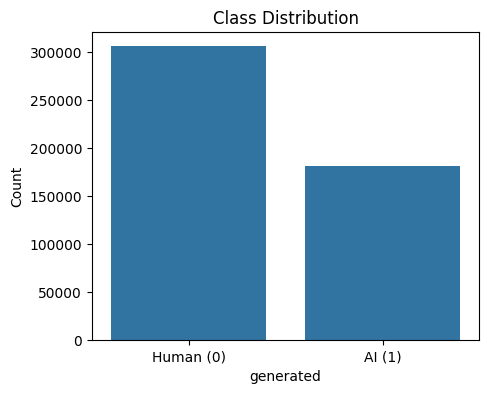

In [60]:
plt.figure(figsize=(5,4))
sns.countplot(x='generated', data=df)
plt.xticks([0,1], ['Human (0)', 'AI (1)'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

In [61]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

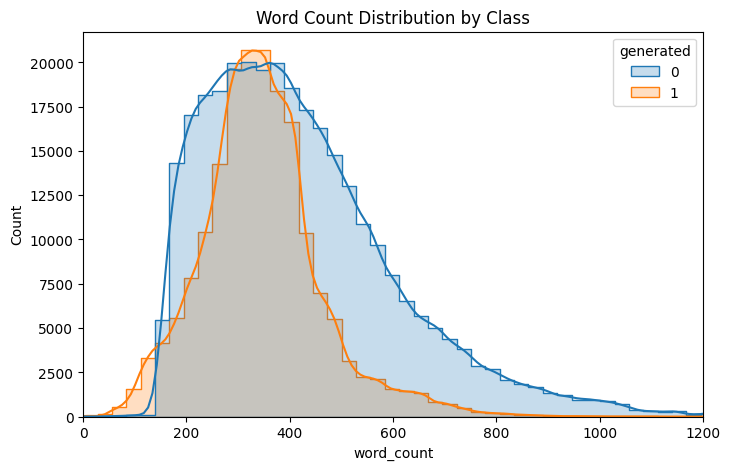

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='word_count', hue='generated', bins=60, kde=True,
             palette={0:'tab:blue', 1:'tab:orange'}, element='step')
plt.title('Word Count Distribution by Class')
plt.xlim(0, 1200)
plt.show()

In [63]:
df.groupby('generated')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
generated,,,,,,,,
0,305797.0,421.98518,186.870962,14.0,281.0,389.0,520.0,1668.0
1,181438.0,344.40653,117.031491,0.0,274.0,337.0,403.0,1238.0


In [64]:
df['char_count'] = df['text'].astype(str).apply(len)
df['avg_word_len'] = df['char_count'] / df['word_count'].replace(0, 1)

In [65]:
print(df.groupby('generated')[['char_count', 'avg_word_len']].mean())

            char_count  avg_word_len
generated                           
0          2354.592838      5.551858
1          2126.316411      6.141562


In [66]:
STOPWORDS = set(stopwords.words('english'))
NEGATIONS = {"no", "not", "nor", "never", "none", "n't"}
STOPWORDS = STOPWORDS - NEGATIONS

In [67]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
HTML_RE = re.compile(r'<.*?>')
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s']")
MULTI_SPACE_RE = re.compile(r'\s+')

In [68]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    try:
        text = contractions.fix(text)
    except Exception:
        pass
    text = NON_ALPHA_RE.sub(' ', text)
    text = MULTI_SPACE_RE.sub(' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

In [69]:
clean_text(df['text'].iloc[0])[:300]

'cars cars around since became famous henry ford created built first modelt cars played major role every day lives since people starting question limiting car usage would good thing limiting use cars might good thing like matter article german suburb life goes without cars elizabeth rosenthal states '

In [70]:
df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [71]:
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

In [72]:
df.shape

(487230, 6)

In [73]:
df[['text', 'clean_text', 'generated']].head()

,text,clean_text,generated
0,Cars. Cars have been around since they became ...,cars cars around since became famous henry for...,0
1,Transportation is a large necessity in most co...,transportation large necessity countries world...,0
2,"""America's love affair with it's vehicles seem...",america's love affair vehicles seems cooling s...,0
3,How often do you ride in a car? Do you drive a...,often ride car drive one motor vehicle work st...,0
4,Cars are a wonderful thing. They are perhaps o...,cars wonderful thing perhaps one worlds greate...,0


In [74]:
df['clean_word_count'] = df['clean_text'].str.split().apply(len)

In [75]:
print("99th percentile:", np.percentile(df['clean_word_count'], 99))

99th percentile: 510.0


In [76]:
print("\n95th percentile:", np.percentile(df['clean_word_count'], 95))


95th percentile: 389.0


In [77]:
import gc

X = df['clean_text'].values
y = df['generated'].values
del df; gc.collect()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
del X_temp, y_temp; gc.collect()

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

Train: 341061  Val: 73084  Test: 73085


In [78]:
VOCAB_SIZE    = 30000
MAX_LEN       = 400
EMBEDDING_DIM = 64
BATCH_SIZE    = 512
EPOCHS        = 15

In [79]:
import re, os, json, pickle, random, gc

In [80]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
print("Vocab size found:", len(tokenizer.word_index))
 
def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post').astype(np.int32)
 
X_train_pad = to_padded(X_train); del X_train; gc.collect()
X_val_pad   = to_padded(X_val);   del X_val;   gc.collect()
X_test_pad  = to_padded(X_test);  del X_test;  gc.collect()
 
print("Shapes:", X_train_pad.shape, X_val_pad.shape, X_test_pad.shape)
print(f"RAM used by train array: {X_train_pad.nbytes / 1e6:.1f} MB")

Vocab size found: 219654
Shapes: (341061, 400) (73084, 400) (73085, 400)
RAM used by train array: 545.7 MB


In [81]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7966555793289669), 1: np.float64(1.3427281245324914)}


In [82]:
 model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN, mask_zero=True),

    layers.Bidirectional(layers.GRU(64, return_sequences=True, implementation=2,
                                     dropout=0.4, recurrent_dropout=0.3)),
    layers.Dropout(0.4),
    layers.Bidirectional(layers.GRU(32, return_sequences=True, implementation=2,
                                     dropout=0.4, recurrent_dropout=0.3)),
    layers.Dropout(0.4),

    layers.GlobalMaxPooling1D(),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(5e-4),  # lower lr from the start
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=1,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_gru_model.keras', monitor='val_loss', mode='min',
                    save_best_only=True, verbose=1)
]
 
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=6,
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7965 - auc: 0.8774 - loss: 0.4273 - precision: 0.7001 - recall: 0.8291
Epoch 1: val_loss improved from None to 0.32548, saving model to best_gru_model.keras

Epoch 1: finished saving model to best_gru_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9134 - auc: 0.9797 - loss: 0.2413 - precision: 0.8514 - recall: 0.9297 - val_accuracy: 0.9896 - val_auc: 0.9992 - val_loss: 0.3255 - val_precision: 0.9957 - val_recall: 0.9763 - learning_rate: 5.0000e-04
Epoch 2/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9907 - auc: 0.9988 - loss: 0.0725 - precision: 0.9860 - recall: 0.9891
Epoch 2: val_loss improved from 0.32548 to 0.15938, saving model to best_gru_model.keras

Epoch 2: finished saving model to best_gru_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 669s 4s/step - accuracy: 0.9922 - auc: 0.9990 - loss: 0.0634 - precision: 0.9886 - recall: 0.9905 - val_accuracy: 0.9926 - val_auc: 0.9997 - val_loss: 0.1

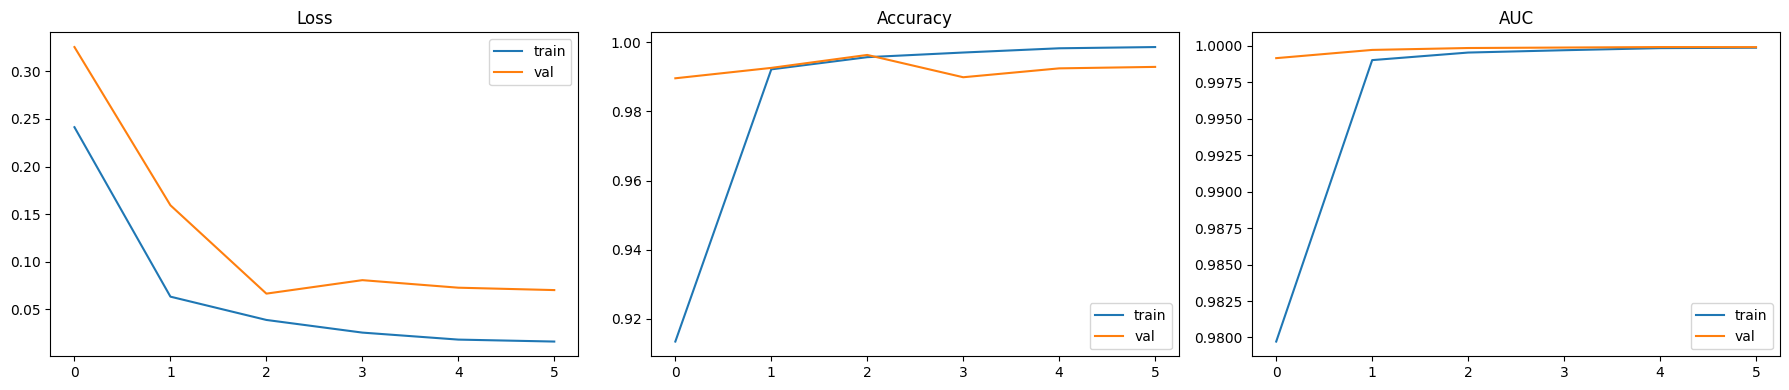

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history.history['auc'], label='train')
axes[2].plot(history.history['val_auc'], label='val')
axes[2].set_title('AUC'); axes[2].legend()

plt.tight_layout()
plt.show()

In [89]:
model.save_weights("gru_model.weights.h5")

In [101]:
best_model = keras.models.load_model('best_gru_model.keras')

test_loss, test_acc, test_auc, test_prec, test_rec = best_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


KeyboardInterrupt: 

In [92]:
y_pred_prob = best_model.predict(X_test_pad, batch_size=128).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

571/571 ━━━━━━━━━━━━━━━━━━━━ 364s 637ms/step


In [93]:
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     45870
          AI       0.99      1.00      1.00     27215

    accuracy                           1.00     73085
   macro avg       1.00      1.00      1.00     73085
weighted avg       1.00      1.00      1.00     73085



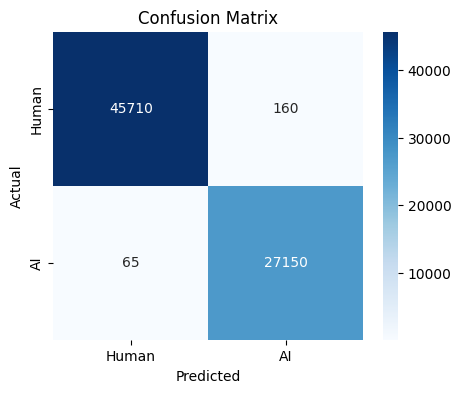

In [94]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

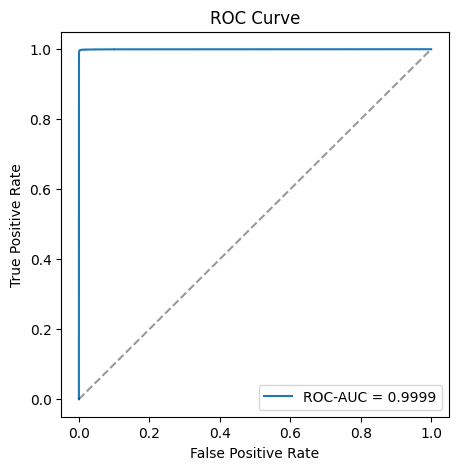

In [95]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_pred_prob):.4f}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.show()

In [96]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
print(f"Best threshold: {thresholds[best_idx]:.3f},  F1: {f1_scores[best_idx]:.4f}")

Best threshold: 0.641,  F1: 0.9966


In [97]:
def predict_text(text, model, tokenizer, max_len=MAX_LEN, threshold=0.5):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = float(model.predict(padded, verbose=0)[0][0])
    label = 'AI-generated' if prob >= threshold else 'Human-written'
    return {'label': label, 'ai_probability': round(prob, 4)}

In [100]:
sample_text = "A .keras file is nothing but a ZIP file. As you have already verified that the file is a valid ZIP file, we can simply unzip it and load its content (model.weights.h5) into the manually defined model."
print(predict_text(sample_text, best_model, tokenizer))

{'label': 'Human-written', 'ai_probability': 0.4263}


In [103]:
model.save('ai_human_gru_model_2.keras')

with open('tokenizer_2.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

config = {
    'max_len': MAX_LEN,
    'vocab_size': VOCAB_SIZE,
    'best_threshold': float(thresholds[best_idx])
}
with open('config.json', 'w') as f:
    json.dump(config, f)

print("Saved: ai_human_gru_model.keras, tokenizer.pickle, config.json")

Saved: ai_human_gru_model.keras, tokenizer.pickle, config.json
